#**1. Linear Regression - Titanic survivors**


In [1]:
!pip install -q sklearn
!pip install -U tensorflow-estimator

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [2]:
%tensorflow_version 2.x  # this line is not required unless you are in a notebook

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [3]:
from __future__ import absolute_import, division, print_function, unicode_literals

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from six.moves import urllib

import tensorflow.compat.v2.feature_column as fc

import tensorflow as tf

In [81]:
# Load dataset.

# working public dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# create train/test split like TensorFlow tutorial
dftrain = df.sample(frac=0.8, random_state=42)
dfeval = df.drop(dftrain.index)

y_train = dftrain.pop('Survived')
y_eval = dfeval.pop('Survived')


In [5]:
dftrain.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C


In [6]:
dftrain.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,713.000000,713.000000,569.000000,713.000000,713.00000,713.000000
mean,447.509116,2.312763,29.531933,0.518934,0.41094,32.970202
std,257.341099,0.832329,14.934686,1.078385,0.83346,52.323284
min,1.000000,1.000000,0.420000,0.000000,0.00000,0.000000
25%,227.000000,2.000000,20.500000,0.000000,0.00000,7.925000
50%,442.000000,3.000000,28.000000,0.000000,0.00000,14.500000
75%,668.000000,3.000000,38.000000,1.000000,1.00000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.00000,512.329200


In [7]:
dftrain.shape

(713, 11)

In [8]:
y_train.head()

,Survived
709,1
439,0
840,0
720,1
39,1


<Axes: >

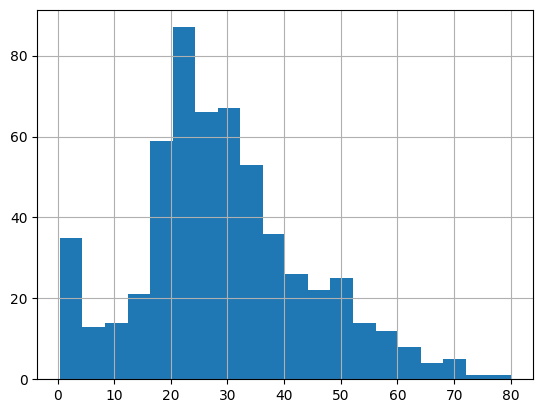

In [9]:
dftrain.Age.hist(bins=20)

<Axes: ylabel='Sex'>

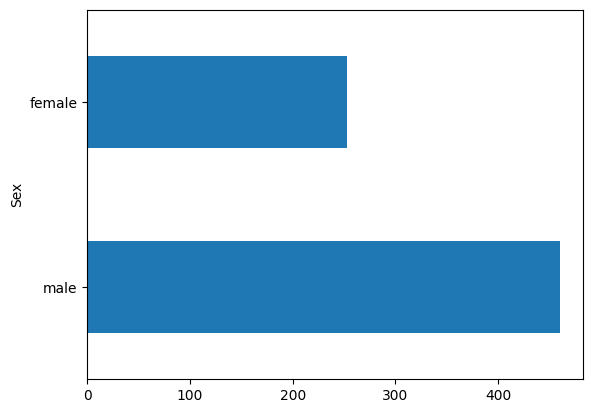

In [10]:
dftrain.Sex.value_counts().plot(kind='barh')

<Axes: ylabel='Pclass'>

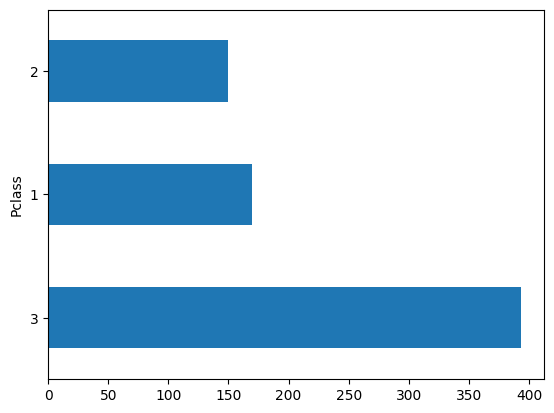

In [11]:
dftrain['Pclass'].value_counts().plot(kind='barh')

Text(0.5, 0, '% survive')

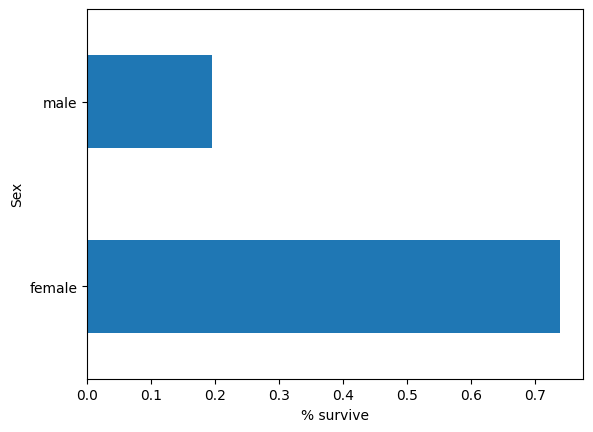

In [12]:
pd.concat([dftrain, y_train], axis=1).groupby('Sex').Survived.mean().plot(kind='barh').set_xlabel('% survive')

In [82]:
dftrain = dftrain.drop(['Cabin','Name','PassengerId','Ticket'], axis=1, errors='ignore')
dfeval = dfeval.drop(['Cabin','Name','PassengerId','Ticket'], axis=1, errors='ignore')


In [83]:
for df in [dftrain, dfeval]:
    df['Sex'] = df['Sex'].map({'male':0,'female':1})
    df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})
    df.fillna(0, inplace=True)


In [84]:
X_train = dftrain.values.astype('float32')
X_eval  = dfeval.values.astype('float32')

X_train[:, [4,5]] = X_train[:, [4,5]] / X_train[:, [4,5]].max(axis=0)
X_eval[:, [4,5]]  = X_eval[:, [4,5]] / X_eval[:, [4,5]].max(axis=0)


In [85]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train.values, epochs=50, batch_size=32, verbose=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4794 - loss: 1.0248
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6467 - loss: 0.6575 
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6428 - loss: 0.6374 
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6248 - loss: 0.6256 
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6895 - loss: 0.5923 
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7204 - loss: 0.5614 
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7517 - loss: 0.5475 
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7656 - loss: 0.5295 
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8036 - loss: 0.5057 
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7871 - loss: 0.5026 
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7713 - loss: 0.5221 
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


<Axes: title={'center': 'Predicted probabilities'}, ylabel='Frequency'>

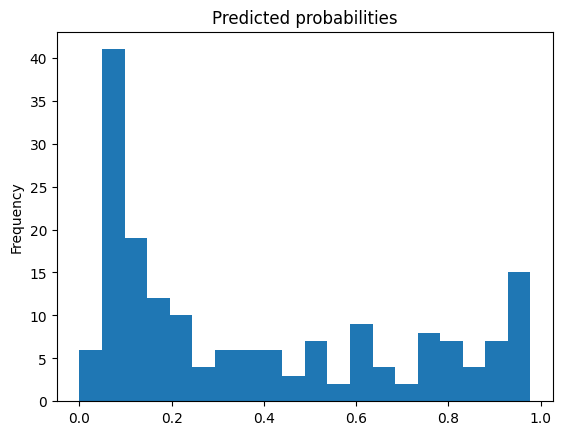

In [86]:
probs = pd.Series(model.predict(X_eval).flatten())
probs.plot(kind='hist', bins=20, title='Predicted probabilities')
